# Práctica: Comparación de modelos de regresión

**Materia:** Tópicos de Big Data
**Tema:** Introducción al aprendizaje supervisado mediante modelos de regresión
**Herramientas:** Python · Jupyter Notebook · Pandas · NumPy · Matplotlib · Scikit-learn

---

## 1. Objetivo

Construir diferentes modelos de aprendizaje supervisado para realizar **proyecciones del número de nacimientos y defunciones** de un país, utilizando datos históricos.

Durante la práctica se implementarán y compararán visualmente tres modelos:

1. Regresión lineal
2. Regresión polinomial
3. Random Forest Regressor

Al finalizar, podrás observar cómo **diferentes modelos generan predicciones diferentes utilizando exactamente los mismos datos**.

> **Nota:** En esta práctica **no** se realizará todavía la evaluación formal de los modelos. La evaluación mediante métricas se realizará en la siguiente sesión.

---

## 2. Dataset

Utilizaremos información de **Our World in Data (OWID)** sobre nacimientos y defunciones, que incluye datos históricos y proyecciones hasta el año 2100.

Fuente: *Our World in Data – Births and deaths projected to 2100* (basado en las estimaciones y proyecciones de la ONU).

El dataset contiene información por **país (o región) y año**.

# PARTE 1. Importar las bibliotecas

En esta práctica utilizaremos:

* **Pandas** para trabajar con el dataset.
* **NumPy** para trabajar con arreglos y preparar datos.
* **Matplotlib** para visualizar los datos y las predicciones.
* **Scikit-learn** para construir los modelos de Machine Learning.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

# PARTE 2. Cargar el dataset

## 3. Cargar los datos

Leemos el archivo CSV directamente desde la página de OWID.

> **Si no hay internet (o la descarga falla):** descarga el CSV desde la URL de la celda siguiente, guárdalo en la misma carpeta que este notebook con el nombre `births-and-deaths-projected-to-2100.csv` y vuelve a ejecutar la celda. El código lo detecta automáticamente.

In [57]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={
            "User-Agent": "Our World In Data data fetch/1.0"
        }
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local 'births-and-deaths-projected-to-2100.csv'")
    df = pd.read_csv("births-and-deaths-projected-to-2100.csv")

df.head()

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


## 4. Explorar el dataset

Observemos la estructura del `DataFrame`.

In [58]:
print("Dimensiones (filas, columnas):", df.shape)
print()
print("Columnas:")
for columna in df.columns:
    print("  -", columna)

Dimensiones (filas, columnas): (39562, 7)

Columnas:
  - entity
  - code
  - year
  - deaths__sex_all__age_all__variant_estimates
  - deaths__sex_all__age_all__variant_medium__projected
  - births__sex_all__age_all__variant_estimates
  - births__sex_all__age_all__variant_medium__projected


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39562 entries, 0 to 39561
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   entity                                               39562 non-null  object 
 1   code                                                 38354 non-null  object 
 2   year                                                 39562 non-null  int64  
 3   deaths__sex_all__age_all__variant_estimates          18944 non-null  float64
 4   deaths__sex_all__age_all__variant_medium__projected  19712 non-null  float64
 5   births__sex_all__age_all__variant_estimates          19166 non-null  float64
 6   births__sex_all__age_all__variant_medium__projected  19943 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 2.1+ MB


In [60]:
df.head(10)

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN
5,Afghanistan,AFG,1955,286725.0,NaN,417650.0,NaN
6,Afghanistan,AFG,1956,286654.0,NaN,425071.0,NaN
7,Afghanistan,AFG,1957,286114.0,NaN,432044.0,NaN
8,Afghanistan,AFG,1958,285911.0,NaN,439867.0,NaN
9,Afghanistan,AFG,1959,285500.0,NaN,447510.0,NaN


Revisemos las entidades disponibles:

In [61]:
print("Número de entidades:", df["entity"].nunique())
df["entity"].unique()

Número de entidades: 262


array(['Afghanistan', 'Africa', 'Africa (UN)', 'Albania', 'Algeria',
       'American Samoa', 'Americas (UN)', 'Andorra', 'Angola', 'Anguilla',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Asia',
       'Asia (UN)', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas',
       'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium',
       'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia',
       'Bonaire Sint Eustatius and Saba', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Cape Verde', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cuba', 'Curacao', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt'

### Pregunta

**¿Cuál es la unidad de observación de cada fila del dataset?**

*Cada fila representa el número de nacimientos y defunciones deuna entidad en un año específico.*



## 5. Preparar los nombres de las columnas

Al explorar el dataset notamos dos cosas:

1. Los nombres de las columnas son largos y difíciles de escribir.
2. Los **datos históricos** (`..._variant_estimates`) y las **proyecciones de la ONU** (`..._variant_medium__projected`) vienen en **columnas separadas**. Cuando una fila es histórica, la columna de proyección está vacía (`NaN`), y viceversa.

Vamos a renombrar las columnas y a crear dos columnas unificadas, `births` y `deaths`, que contengan el dato histórico cuando existe y la proyección de OWID cuando no.

In [62]:
df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})


df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [63]:
df_inicial = df.copy()
df_inicial.head(3)

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN


In [64]:
# Columna unificada: dato histórico si existe; si no, la proyección de OWID
df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])
df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0


# PARTE 3. Seleccionar un país

## 6. Seleccionar México

Para esta práctica utilizaremos México.

In [65]:
pais = "Mexico"

df_mexico = df[df["Entity"] == pais]

df_mexico.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22801,Mexico,MEX,1950,596771.0,NaN,1358501.0,NaN,1358501.0,596771.0
22802,Mexico,MEX,1951,588791.0,NaN,1392106.0,NaN,1392106.0,588791.0
22803,Mexico,MEX,1952,582415.0,NaN,1423352.0,NaN,1423352.0,582415.0
22804,Mexico,MEX,1953,565876.0,NaN,1454762.0,NaN,1454762.0,565876.0
22805,Mexico,MEX,1954,552321.0,NaN,1488719.0,NaN,1488719.0,552321.0


In [66]:
print("Rango de años:", df_mexico["Year"].min(), "-", df_mexico["Year"].max())
print("Número de filas:", df_mexico.shape[0])

Rango de años: 1950 - 2100
Número de filas: 151


## 7. Revisar las variables disponibles

Identifica las columnas correspondientes a: **año**, **nacimientos** y **defunciones**.

In [67]:
df_mexico.columns

Index(['Entity', 'Code', 'Year', 'deaths_estimates', 'deaths_projected',
       'births_estimates', 'births_projected', 'births', 'deaths'],
      dtype='object')

Para esta práctica utilizaremos:

```text
Year
births
deaths
```

# PARTE 4. Explorar visualmente los datos

## 8. Nacimientos a través del tiempo

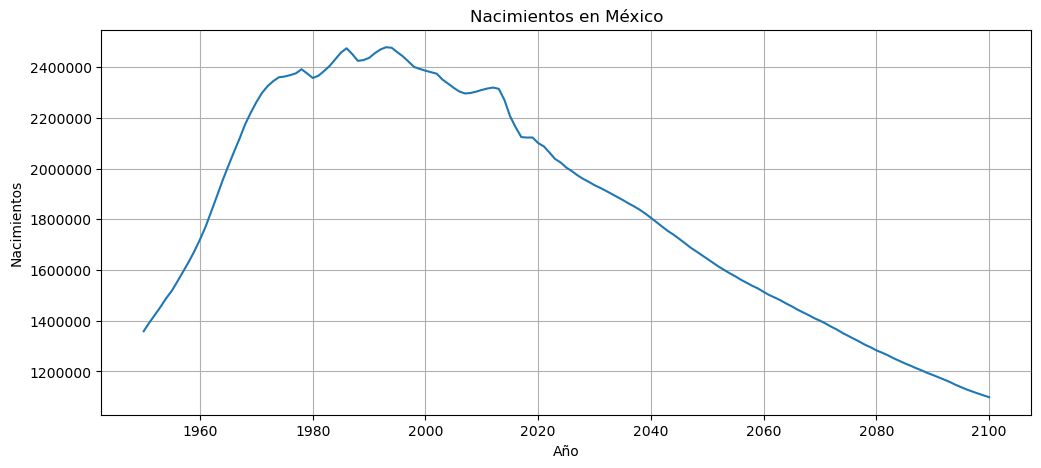

In [68]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_mexico["Year"],
    df_mexico["births"]
)

plt.title("Nacimientos en México")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

## 9. Defunciones a través del tiempo

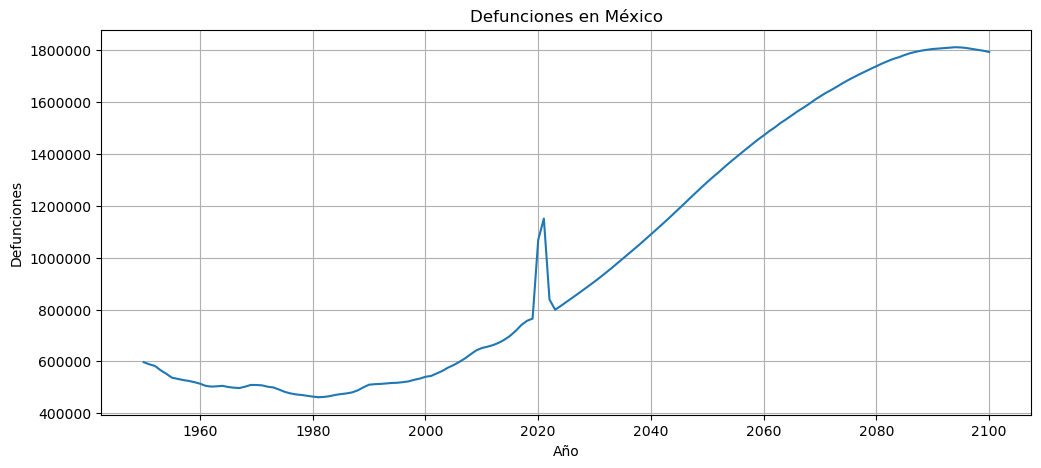

In [69]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_mexico["Year"],
    df_mexico["deaths"]
)

plt.title("Defunciones en México")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

### Preguntas de observación

*
1. ¿Los nacimientos presentan una tendencia constante?
En los últimos años sí, hay una dentencia constante a la baja. Sobretodo en la proyección. Sin embargo, desde el inicio del dataset no. Antes crecían fuertemente, llegaron a su cúspide en los 90's y luego comenzaron a la baja.
2. ¿Las defunciones presentan una tendencia constante? No, se mantenían relativamente bajas, tuvieron un pico en la pandemia y en la proyección si hay una tendencia constante a la alza.
3. ¿Las dos variables parecen seguir el mismo comportamiento? No siguen el mismo comportamiento. Los nacimientos muestran un crecimiento y luego decrecimiento tipo joroba. Las defunciones muestran una tendencia creciente casi constante en los últimos años con el pico en 2020. Tiene sentido, pues conforme la población envejece, hay más defunciones y menos nacimientos.
4. ¿Observas cambios en la tendencia a través del tiempo? Sí, con el paso de los años fue habiendo menos nacimientos y más defunciones y la tendencia a futuro es que cada vez nazcan menos y mueran más.
*

# PARTE 5. Separar datos históricos y proyectados

## 10. Identificar el punto de separación

El dataset contiene **datos históricos** y **proyecciones**. Antes de separarlos, verifiquemos dónde termina uno y empieza el otro:

In [70]:
ultimo_historico = df_mexico.loc[df_mexico["births_estimates"].notna(), "Year"].max()
primera_proyeccion = df_mexico.loc[df_mexico["births_projected"].notna(), "Year"].min()

print("Último año con dato histórico:", ultimo_historico)
print("Primer año con proyección de OWID:", primera_proyeccion)

Último año con dato histórico: 2023
Primer año con proyección de OWID: 2024


Para esta práctica utilizaremos como punto de separación el **año 2023**. Creamos dos `DataFrames`:

In [71]:
df_historico = df_mexico[
    (df_mexico["Year"] >= 1980) & (df_mexico["Year"] <= 2023)
]

df_proyectado = df_mexico[
    df_mexico["Year"] > 2023
]

print(df_historico.head(3))
print(df_proyectado.head(3))

       Entity Code  Year  deaths_estimates  deaths_projected  \
22831  Mexico  MEX  1980          464115.0               NaN   
22832  Mexico  MEX  1981          461670.0               NaN   
22833  Mexico  MEX  1982          462853.0               NaN   

       births_estimates  births_projected     births    deaths  
22831         2357249.0               NaN  2357249.0  464115.0  
22832         2366047.0               NaN  2366047.0  461670.0  
22833         2384613.0               NaN  2384613.0  462853.0  
       Entity Code  Year  deaths_estimates  deaths_projected  \
22875  Mexico  MEX  2024               NaN          813823.0   
22876  Mexico  MEX  2025               NaN          829063.0   
22877  Mexico  MEX  2026               NaN          844431.0   

       births_estimates  births_projected     births    deaths  
22875               NaN         2023623.0  2023623.0  813823.0  
22876               NaN         2003673.0  2003673.0  829063.0  
22877               NaN        

In [72]:
print("Histórico  ->", df_historico.shape, "| años:", df_historico["Year"].min(), "a", df_historico["Year"].max())
print("Proyectado ->", df_proyectado.shape, "| años:", df_proyectado["Year"].min(), "a", df_proyectado["Year"].max())

Histórico  -> (44, 9) | años: 1980 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


Comprobemos que no haya valores faltantes en las variables que vamos a utilizar para entrenar:

In [73]:
df_historico[["Year", "births", "deaths"]].isna().sum()

Year      0
births    0
deaths    0
dtype: int64

# PARTE 6. Preparar las variables para Machine Learning

## 11. Definir X e y

Para nuestro primer modelo utilizaremos:

* **X:** año → la **variable predictora**
* **y:** número de nacimientos → la **variable objetivo**

In [74]:
X = df_historico[["Year"]]
y_nacimientos = df_historico["births"]

In [75]:
X.head()

,Year
22831,1980
22832,1981
22833,1982
22834,1983
22835,1984


In [76]:
y_nacimientos.head()

22831    2357249.0
22832    2366047.0
22833    2384613.0
22834    2404958.0
22835    2431036.0
Name: births, dtype: float64

## 12. Convertir los datos a NumPy

Obtenemos los valores como arreglos de NumPy:

In [77]:
X_numpy = X.to_numpy()
y_numpy = y_nacimientos.to_numpy()

print("X_numpy.shape:", X_numpy.shape)
print("y_numpy.shape:", y_numpy.shape)

X_numpy.shape: (44, 1)
y_numpy.shape: (44,)


In [78]:
type(X_numpy), type(y_numpy)

(numpy.ndarray, numpy.ndarray)

### Observación

Scikit-learn espera normalmente que las variables predictoras tengan la forma:

```text
(número de observaciones, número de variables)
```
Es decir, que scikit-learn interpreta X como una tabla de datos.

Por eso `X` tiene **dos dimensiones**, mientras que `y` tiene una sola.

En nuestro ejemplo tenemos:

74 observaciones (registros).

1 variable predictora: año (estas son las caracteristicas o atributos usadas para la predicción).

1 variable objetivo: nacimientos (valor que deseamos predecir).

# PARTE 7. Modelo 1 – Regresión lineal

## 13. Crear el modelo

In [79]:
modelo_lineal = LinearRegression()

## 14. Entrenar el modelo

Utilizamos los datos históricos para entrenar el modelo.

In [80]:
modelo_lineal.fit(X, y_nacimientos)

LinearRegression()

Una regresión lineal aprende una recta `y = a·x + b`. Veamos qué valores aprendió:

In [81]:
print("Pendiente (a):", modelo_lineal.coef_[0])
print("Intercepto (b):", modelo_lineal.intercept_)

Pendiente (a): -8434.048273431992
Intercepto (b): 19210679.00563777


## 15. Realizar predicciones

Utilizamos el modelo para estimar los nacimientos correspondientes a los **años históricos**.

In [82]:
predicciones_lineal = modelo_lineal.predict(X)

predicciones_lineal[:10]

array([2511263.42424242, 2502829.37596899, 2494395.32769556,
       2485961.27942213, 2477527.2311487 , 2469093.18287526,
       2460659.13460183, 2452225.0863284 , 2443791.03805497,
       2435356.98978154])

## 16. Realizar proyecciones hasta 2100

Creamos los años para los que queremos generar **nuestras propias proyecciones**.

In [83]:
anios_futuros = np.arange(2024, 2101).reshape(-1, 1)

print("Forma:", anios_futuros.shape)
anios_futuros[:10]

Forma: (77, 1)


array([[2024],
       [2025],
       [2026],
       [2027],
       [2028],
       [2029],
       [2030],
       [2031],
       [2032],
       [2033]])

> **Detalle técnico:** entrenamos el modelo con `X`, que es un `DataFrame` con una columna llamada `Year`. Scikit-learn recuerda ese nombre, así que para predecir también debemos entregarle un `DataFrame` con una columna `Year`. Si le pasáramos un arreglo de NumPy "a secas" mostraría una advertencia (*UserWarning: X does not have valid feature names*). Por eso convertimos los años futuros a `DataFrame`.

In [84]:
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

X_futuro.head()

,Year
0,2024
1,2025
2,2026
3,2027
4,2028


In [85]:
predicciones_lineal_futuras = modelo_lineal.predict(X_futuro)

In [86]:
print(predicciones_lineal_futuras[:10])

[2140165.30021142 2131731.25193799 2123297.20366455 2114863.15539112
 2106429.10711769 2097995.05884426 2089561.01057082 2081126.96229739
 2072692.91402396 2064258.86575053]


# PARTE 8. Visualizar la regresión lineal

## 17. Comparar datos históricos y predicciones

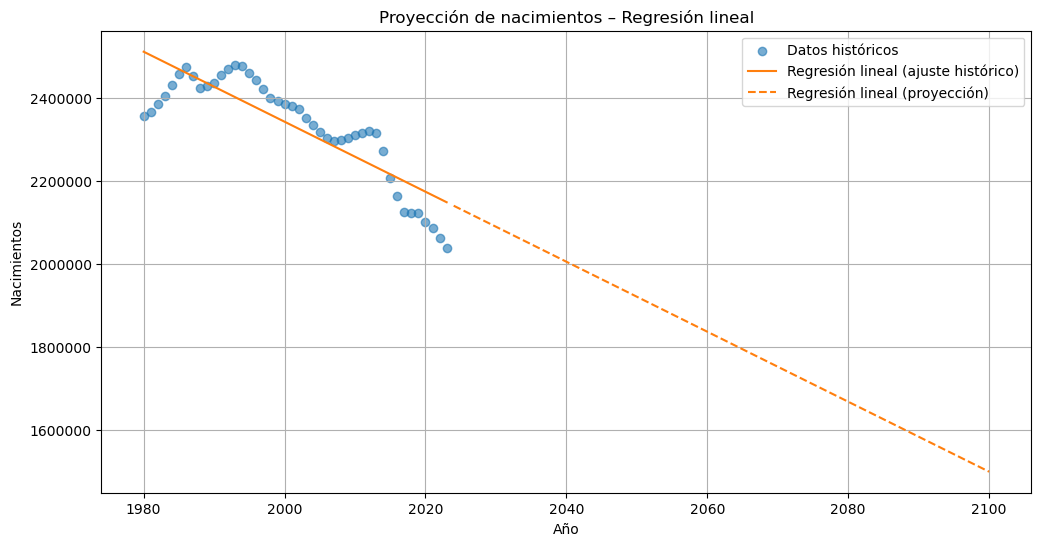

In [87]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

# Ajuste del modelo sobre los años históricos
plt.plot(
    df_historico["Year"],
    predicciones_lineal,
    color="tab:orange",
    label="Regresión lineal (ajuste histórico)"
)

# Proyección hacia el futuro
plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    linestyle="--",
    label="Regresión lineal (proyección)"
)

plt.title("Proyección de nacimientos – Regresión lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación

Analiza cómo continúa la tendencia histórica cuando utilizamos una **función lineal**. ¿Qué pasa con los valores hacia el año 2100?

*Siguen escalando verticalmente de manera continua, en línea recta. No vemos altas ni bajas, pues el modelo solo capta una pendiente promedio positiva. En realidad los datos históricos recientes muestran una disminución, por lo que este es un ejemplo de extrapolación poco realista.*

# PARTE 9. Modelo 2 – Regresión polinomial

## 18. Crear variables polinomiales

La regresión lineal solamente puede representar una relación **lineal** entre las variables. Ahora construiremos variables polinomiales para permitir **curvas**. Utilizaremos un polinomio de **grado 2**:

$$y = a \cdot x^2 + b \cdot x + c$$

In [88]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

Transformamos `X`:

In [89]:
X_poly = poly.fit_transform(X)

X_poly[:5]

array([[1.980000e+03, 3.920400e+06],
       [1.981000e+03, 3.924361e+06],
       [1.982000e+03, 3.928324e+06],
       [1.983000e+03, 3.932289e+06],
       [1.984000e+03, 3.936256e+06]])

Observa que ahora cada año tiene **dos columnas**: el año (`x`) y el año al cuadrado (`x²`).

## 19. Crear y entrenar el modelo polinomial

Seguimos utilizando `LinearRegression`; lo único que cambió son las **variables de entrada**.

In [90]:
modelo_polinomial = LinearRegression()

modelo_polinomial.fit(
    X_poly,
    y_nacimientos
)

LinearRegression()

## 20. Generar predicciones históricas

In [91]:
predicciones_polinomiales = modelo_polinomial.predict(
    X_poly
)

## 21. Generar proyecciones hasta 2100

Transformamos los años futuros utilizando **el mismo objeto `poly`** con el que transformamos los datos de entrenamiento.

In [92]:
anios_futuros_poly = poly.transform(
    X_futuro
)

predicciones_polinomiales_futuras = modelo_polinomial.predict(
    anios_futuros_poly
)

# PARTE 10. Visualizar la regresión polinomial

## 22. Graficar las predicciones

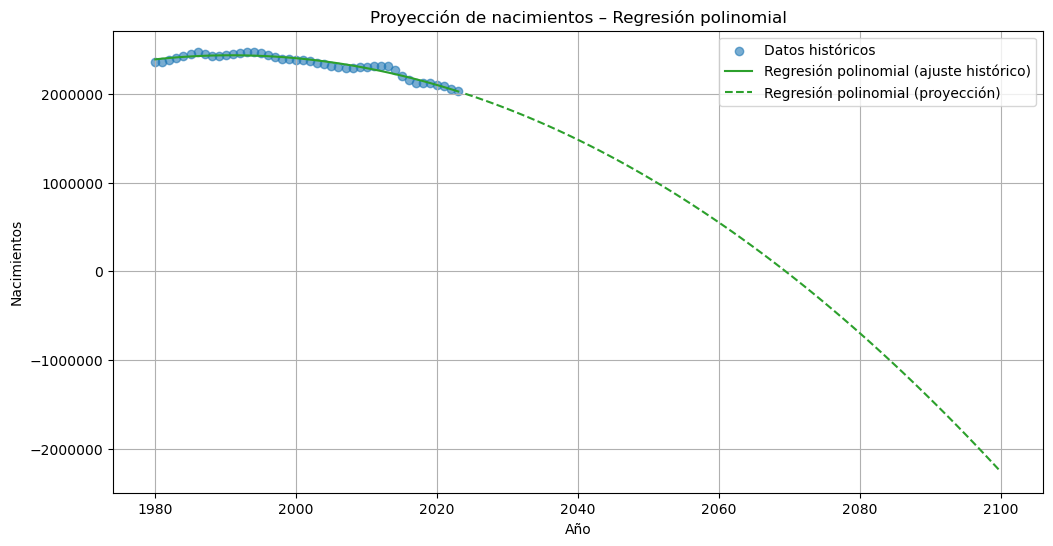

In [93]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_polinomiales,
    color="tab:green",
    label="Regresión polinomial (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    linestyle="--",
    label="Regresión polinomial (proyección)"
)

plt.title("Proyección de nacimientos – Regresión polinomial")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación

Compara el comportamiento de esta gráfica con el modelo de regresión lineal. ¿Se ajusta mejor a los datos históricos? ¿Qué ocurre con la proyección hacia el año 2100? ¿Los valores que predice tienen sentido para un número de nacimientos?

*Sí, se ajusta mejor a los datos históricos, pues al permitir la curva, logra seguir con más precisión la forma de joroba que tienen los datos. COn la proyección hacia el año 21000 los datos que predica ya no tienen sentido, pues como la parábola ya venía bajando al final del periodo histórico, al extrapolar hacia 2100 la curva se desploma y empieza a predecir valores negativos, lo que no tiene sentido para la edad.*

# PARTE 11. Modelo 3 – Random Forest

## 23. Crear el modelo

Un **Random Forest** está formado por muchos árboles de decisión. Utilizaremos `RandomForestRegressor`.

In [94]:
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

## 24. Entrenar el modelo

In [95]:
modelo_rf.fit(
    X,
    y_nacimientos
)

RandomForestRegressor(random_state=42)

## 25. Generar predicciones históricas

In [96]:
predicciones_rf = modelo_rf.predict(X)

## 26. Generar proyecciones futuras

In [97]:
predicciones_rf_futuras = modelo_rf.predict(
    X_futuro
)

# PARTE 12. Visualizar Random Forest

## 27. Graficar las predicciones

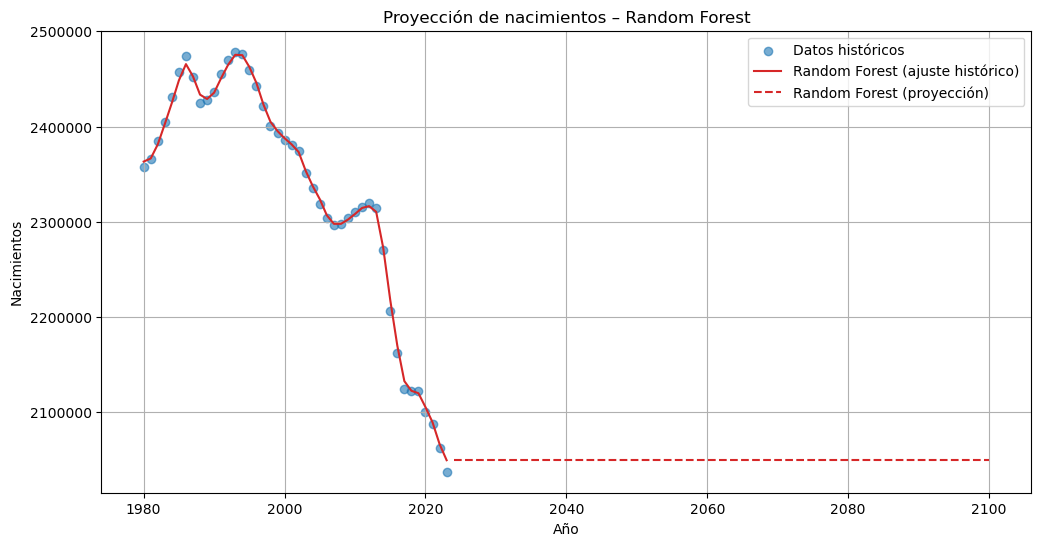

In [98]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_rf,
    color="tab:red",
    label="Random Forest (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    linestyle="--",
    label="Random Forest (proyección)"
)

plt.title("Proyección de nacimientos – Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación

Fíjate en dos cosas: (1) qué tan bien sigue el modelo los datos históricos y (2) qué sucede con la línea después de 2023. ¿Continúa la tendencia? ¿Por qué crees que sucede esto? Investiga.

Random forest sigue a los datos casi a la perfección, mucho mejor que regresión lineal y un poco mejor que polinomial, pues está formado por muchis árboles de decisión. Después de 2023 la predicción no continúa con tendencias, la línea se vuelve completamente recta cerca de 2,050 y se mantiene así, esto porque un árbol de decisión predice promediando los valores de entrenamiento que caen en la misma "Hoja" y como nunca fue entrenado con años posteriores a 2023, no tiene ninguna hoja de esos años y simplemente repite la predicción.

# PARTE 13. Comparar los tres modelos

## 28. Graficar los tres modelos

Construimos una gráfica que permita comparar directamente los resultados.

> Si la regresión polinomial genera valores muy extremos y no permite ver bien las demás curvas, puedes limitar el eje vertical agregando, por ejemplo, `plt.ylim(0, 3_500_000)` antes de `plt.show()`.

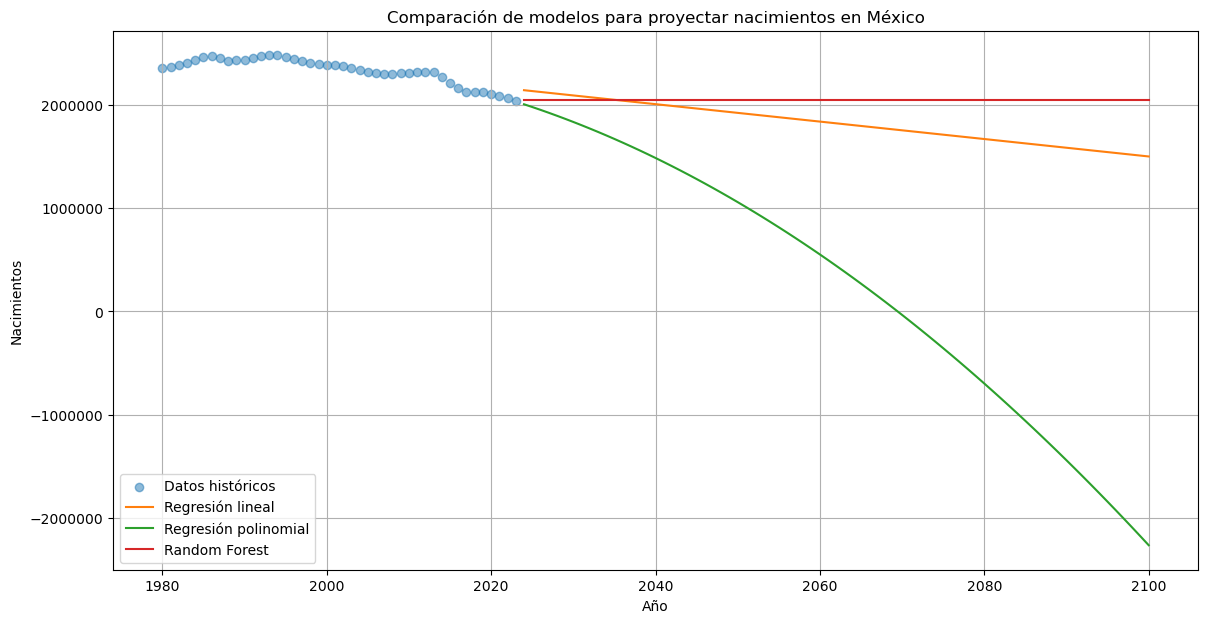

In [99]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Comparación de modelos para proyectar nacimientos en México"
)

plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# PARTE 14. Repetir el proceso para defunciones

Hasta este momento construimos modelos para predecir **nacimientos**. Ahora repetiremos el mismo proceso para **defunciones**.

## 29. Preparar la variable objetivo

La variable predictora sigue siendo `X` (el año). Solo cambia la variable objetivo:

In [100]:
y_defunciones = df_historico["deaths"]

## 30. Regresión lineal para defunciones

In [101]:
modelo_lineal_deaths = LinearRegression()

modelo_lineal_deaths.fit(
    X,
    y_defunciones
)

predicciones_lineal_deaths = modelo_lineal_deaths.predict(
    X_futuro
)

## 31. Regresión polinomial para defunciones

Utilizamos nuevamente las variables construidas con `PolynomialFeatures` (`X_poly` y `anios_futuros_poly`).

In [102]:
modelo_polinomial_deaths = LinearRegression()

modelo_polinomial_deaths.fit(
    X_poly,
    y_defunciones
)

predicciones_polinomiales_deaths = modelo_polinomial_deaths.predict(
    anios_futuros_poly
)

## 32. Random Forest para defunciones

In [103]:
modelo_rf_deaths = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf_deaths.fit(
    X,
    y_defunciones
)

predicciones_rf_deaths = modelo_rf_deaths.predict(
    X_futuro
)

# PARTE 15. Comparar las predicciones de defunciones

## 33. Visualizar los tres modelos

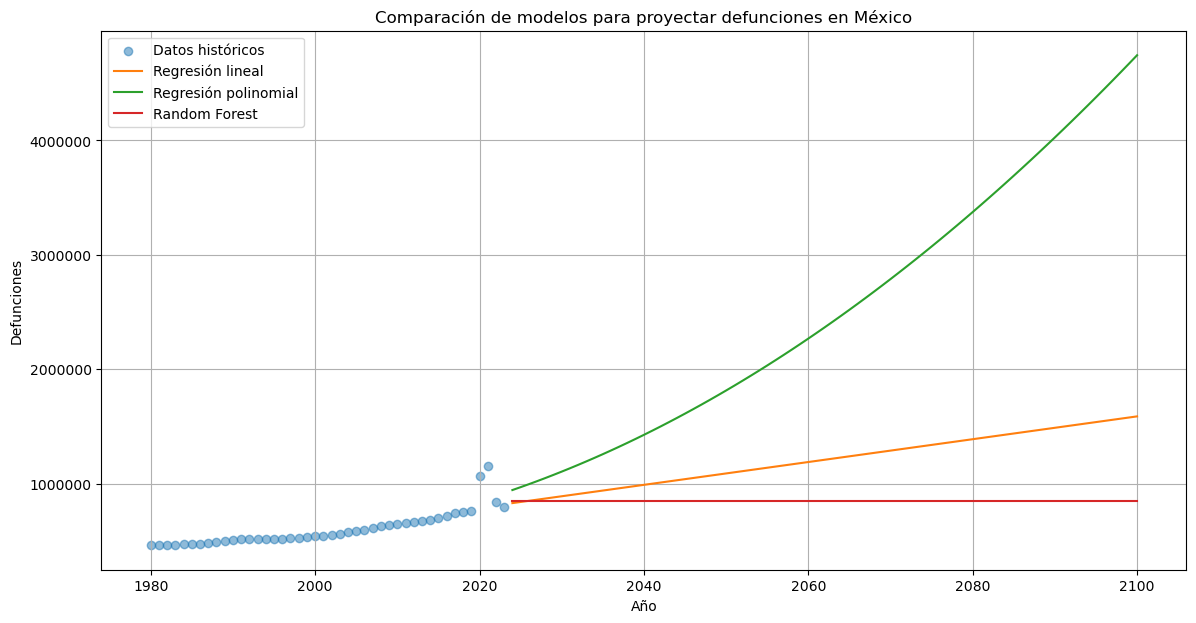

In [104]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_historico["Year"],
    df_historico["deaths"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_deaths,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_deaths,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_deaths,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Comparación de modelos para proyectar defunciones en México"
)

plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# PARTE 16. Comparar nuestros modelos con las proyecciones de OWID

Finalmente, agregamos a las gráficas las **proyecciones proporcionadas por OWID** (las de la ONU, escenario medio). Estas proyecciones no se obtienen ajustando una recta a la serie histórica: se construyen con modelos demográficos que consideran fecundidad, mortalidad y estructura por edad de la población.

## 34. Nacimientos: ML vs OWID

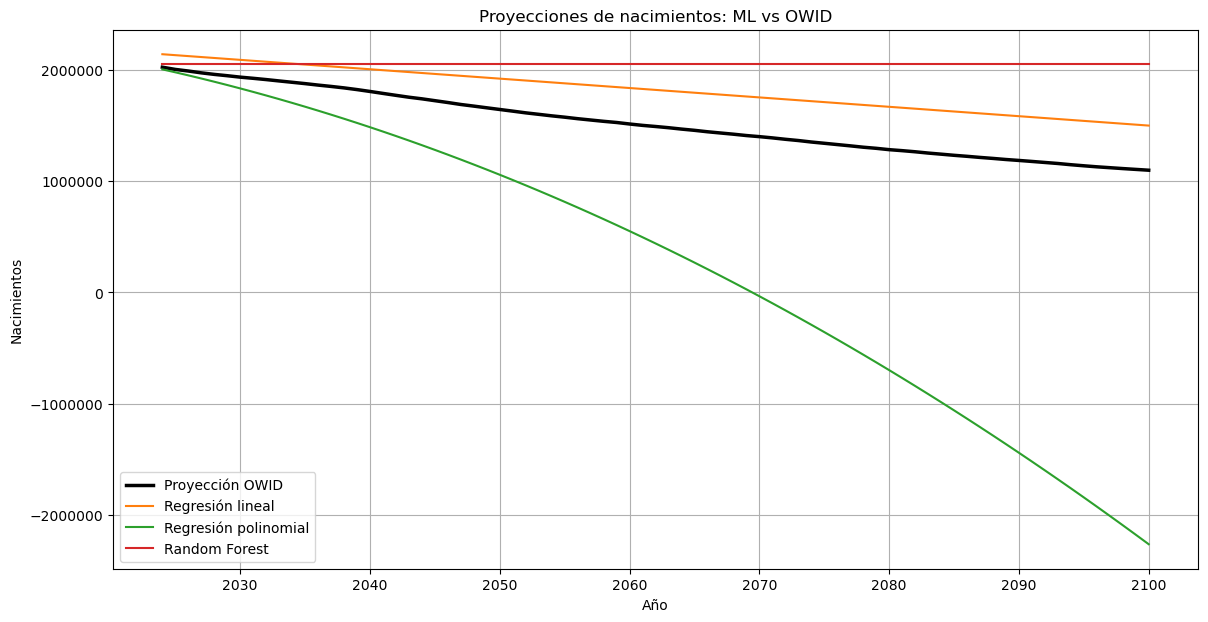

In [105]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_proyectado["Year"],
    df_proyectado["births"],
    color="black",
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Proyecciones de nacimientos: ML vs OWID"
)

plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 35. Defunciones: ML vs OWID

Repetimos el ejercicio para defunciones.

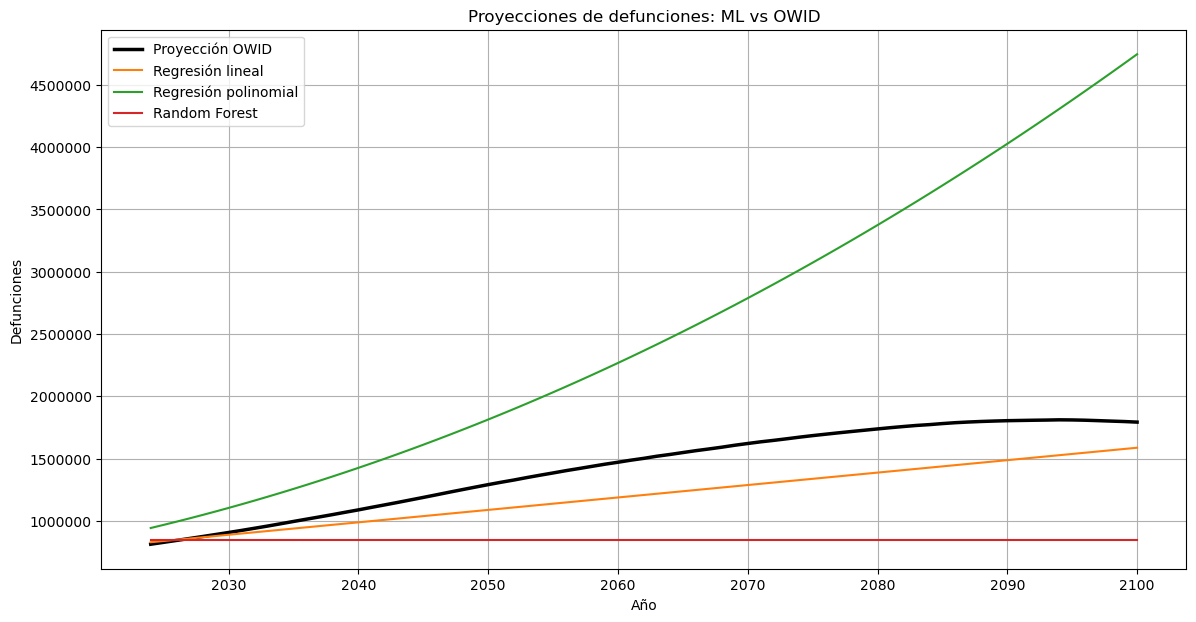

In [106]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_proyectado["Year"],
    df_proyectado["deaths"],
    color="black",
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_deaths,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_deaths,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_deaths,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Proyecciones de defunciones: ML vs OWID"
)

plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 36. Resumen numérico (opcional)

A veces es útil ver los números y no solo la gráfica. Esta tabla muestra lo que predice cada modelo para algunos años seleccionados:

In [107]:
anios_tabla = [2030, 2050, 2075, 2100]
indice = anios_futuros.flatten()


def construir_tabla(owid, lineal, polinomial, rf):
    tabla = pd.DataFrame(
        {
            "OWID": owid.set_index("Year").reindex(indice).to_numpy().ravel(),
            "Regresión lineal": lineal,
            "Regresión polinomial": polinomial,
            "Random Forest": rf,
        },
        index=indice
    )
    tabla.index.name = "Año"
    return tabla.loc[anios_tabla]


print("NACIMIENTOS")
display(
    construir_tabla(
        df_proyectado[["Year", "births"]],
        predicciones_lineal_futuras,
        predicciones_polinomiales_futuras,
        predicciones_rf_futuras
    ).style.format("{:,.0f}")
)

print("DEFUNCIONES")
display(
    construir_tabla(
        df_proyectado[["Year", "deaths"]],
        predicciones_lineal_deaths,
        predicciones_polinomiales_deaths,
        predicciones_rf_deaths
    ).style.format("{:,.0f}")
)

NACIMIENTOS


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"1,934,285","2,089,561","1,832,970","2,049,777"
2050,"1,643,767","1,920,880","1,057,298","2,049,777"
2075,"1,340,246","1,710,029","-355,709","2,049,777"
2100,"1,098,210","1,499,178","-2,261,404","2,049,777"


DEFUNCIONES


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"907,843","889,656","1,105,073","845,495"
2050,"1,291,889","1,089,172","1,814,180","845,495"
2075,"1,685,181","1,338,568","3,072,828","845,495"
2100,"1,793,462","1,587,964","4,745,105","845,495"


# PARTE 17. Reflexión

Responde las siguientes preguntas en esta misma celda (haz doble clic para editarla).

### 1.
¿Qué diferencia observaste entre la regresión lineal, la regresión polinomial y Random Forest?

*Respuesta: La regresión lineal solo puede dibujar una recta, tiene ajuste historico pobre. Regresión polinomial se ajusta mejor al histórico, pero al extrapolar dispara valores absurdos. Y random forest sigue los datos históricos casi perfecto, pero al no poder extrapolar, congela su prediccipón en el último valor conocido.*

### 2.
¿Por qué los tres modelos generan predicciones diferentes si utilizaron los mismos datos históricos?

*Respuesta: Porque cada modelo funciona distinto en la relación entre el año y los nacimientos.*

### 3.
¿Qué modelo produjo una tendencia más cercana visualmente a las proyecciones de OWID?

*Respuesta: Ningun modelo logra imitar bien la tendencia decreciente que muestra el OWID. Random Forest fue el que se mantuvo visualmente más cerca.*

### 4.
¿El modelo que visualmente parece acercarse más a las proyecciones de OWID necesariamente es el mejor modelo? Explica.

*Respuesta: No necesariamente. Aquí no medimos desempeño con ninguna métrica, solo estamos comparando visualmente. Un modelo puede parecerse a otra proyección por razones distintas a que realmente esté caoturado bien el fenómeno.*

### 5.
¿Qué comportamiento observaste en las predicciones de Random Forest para los años posteriores a 2023?

*Respuesta: La predicción se vuelve una línea horizontal hasta el 2100. Esto porque no vio años mayores a 2023 y no tiene forma de generar un valor distinti para ellos.*

### 6.
¿Por qué debemos tener cuidado al utilizar un modelo entrenado con datos históricos para realizar predicciones hasta el año 2100?

*Porque estamos extrapolando muy lejos del rango de datos con el que se entrenó el modelo y ningún modelo estadístico o de machine learning sabe qué pasa fuera del rango. Solo extiende el oatrón matemático que aprendió.*

# PARTE 18. Conceptos clave

Al finalizar la práctica, debes poder identificar:

| Concepto | Significado |
|---|---|
| **Variable predictora** | Variable utilizada por el modelo para generar una predicción |
| **Variable objetivo** | Variable que queremos predecir |
| **Entrenamiento** | Proceso mediante el cual el modelo aprende a partir de los datos |
| **Predicción** | Resultado generado por el modelo |
| **Regresión lineal** | Modelo que representa una relación lineal |
| **Regresión polinomial** | Extensión que permite representar relaciones curvas |
| **Random Forest** | Modelo basado en múltiples árboles de decisión |
| **Extrapolación** | Generación de predicciones fuera del rango de datos utilizados para entrenar el modelo |

> **Importante:** En esta práctica solamente hemos **construido y utilizado** los modelos. En la siguiente práctica aprenderemos a **evaluar su desempeño mediante métricas**, para determinar qué tan bien están realizando sus predicciones.

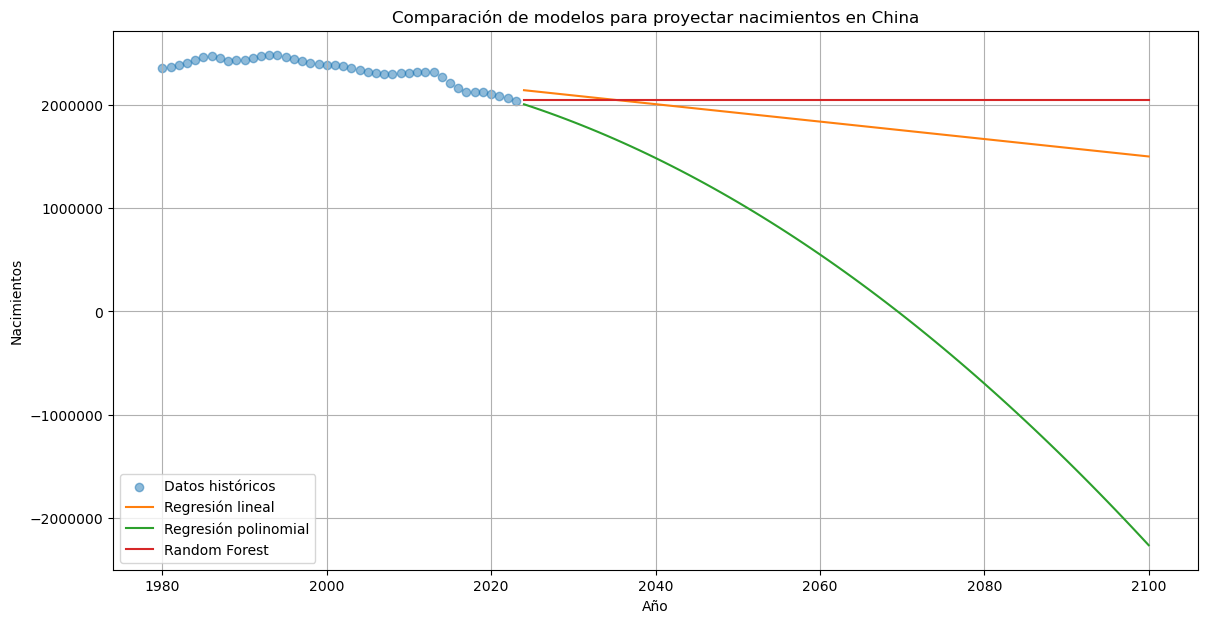

In [108]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Comparación de modelos para proyectar nacimientos en China"
)

plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()